# 🫘 Dry Bean Dataset — Exploratory Data Analysis

## Objective
Gain a comprehensive understanding of the Dry Bean dataset's structure and
characteristics to support more effective machine learning model development.

## Goals
- Explore feature distributions and inter-class differences
- Detect skewness, potential outliers, and multicollinearity
- Assess data quality (missing values, class imbalance)
- Identify the most discriminative features for downstream modelling


## 1 · Imports & Global Settings

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

# ── Consistent plot aesthetics across all figures ──────────────────────────
sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 11,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
})

SEED = 42  # fix randomness for reproducibility


c:\Users\R.A.B\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.6)
  from scipy.stats import gaussian_kde


## 2 · Load Data

In [2]:
df = pd.read_csv("Dry_Bean_Dataset.csv")

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()


Shape: 13,611 rows × 17 columns


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


## 3 · Dataset Overview

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

In [4]:
# Quick summary statistics for all numerical features
df.describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
Area,13611.0,53048.28,29324.10,20420.00,36328.00,44652.00,61332.00,254616.00
Perimeter,13611.0,855.28,214.29,524.74,703.52,794.94,977.21,1985.37
MajorAxisLength,13611.0,320.14,85.69,183.60,253.30,296.88,376.50,738.86
MinorAxisLength,13611.0,202.27,44.97,122.51,175.85,192.43,217.03,460.20
AspectRation,13611.0,1.58,0.25,1.02,1.43,1.55,1.71,2.43
Eccentricity,13611.0,0.75,0.09,0.22,0.72,0.76,0.81,0.91
ConvexArea,13611.0,53768.20,29774.92,20684.00,36714.50,45178.00,62294.00,263261.00
EquivDiameter,13611.0,253.06,59.18,161.24,215.07,238.44,279.45,569.37
Extent,13611.0,0.75,0.05,0.56,0.72,0.76,0.79,0.87
Solidity,13611.0,0.99,0.00,0.92,0.99,0.99,0.99,0.99


**Key observations:**
- **13,611** dry-bean instances across **7** cultivar classes
- **16** numerical features describing physical shape & geometry
- **No missing values** — the dataset is complete and requires no imputation


## 4 · Class Distribution

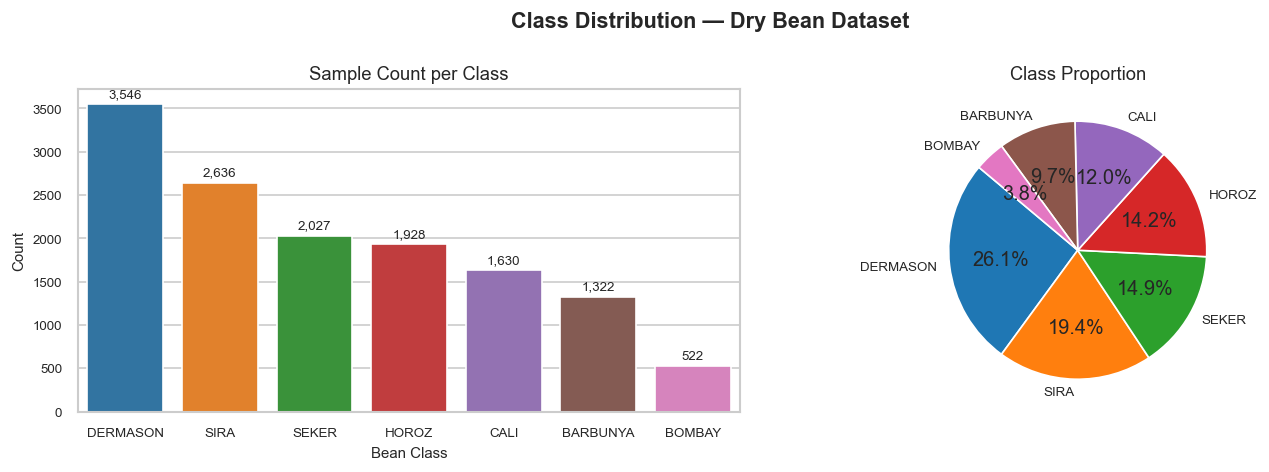

In [5]:
class_counts = df["Class"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Bar chart ─────────────────────────────────────────────────────────────
sns.barplot(x=class_counts.index, y=class_counts.values,
            hue=class_counts.index, palette="tab10", legend=False, ax=axes[0])
axes[0].set_title("Sample Count per Class")
axes[0].set_xlabel("Bean Class")
axes[0].set_ylabel("Count")
for bar, count in zip(axes[0].patches, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
                 f"{count:,}", ha="center", va="bottom", fontsize=8)

# ── Pie chart ─────────────────────────────────────────────────────────────
axes[1].pie(class_counts.values, labels=class_counts.index,
            autopct="%1.1f%%", startangle=140,
            colors=sns.color_palette("tab10", len(class_counts)))
axes[1].set_title("Class Proportion")

plt.suptitle("Class Distribution — Dry Bean Dataset", fontsize=13, weight="bold")
plt.tight_layout()
plt.show()


**Imbalance note:** The dataset is moderately imbalanced.
When training classifiers, consider:
- **Resampling** — oversample minority classes (e.g. SMOTE) or undersample majority ones
- **Class weighting** — set `class_weight='balanced'` in sklearn estimators
- **Evaluation metrics** — prefer macro-F1 / balanced accuracy over raw accuracy


## 5 · Feature Distributions

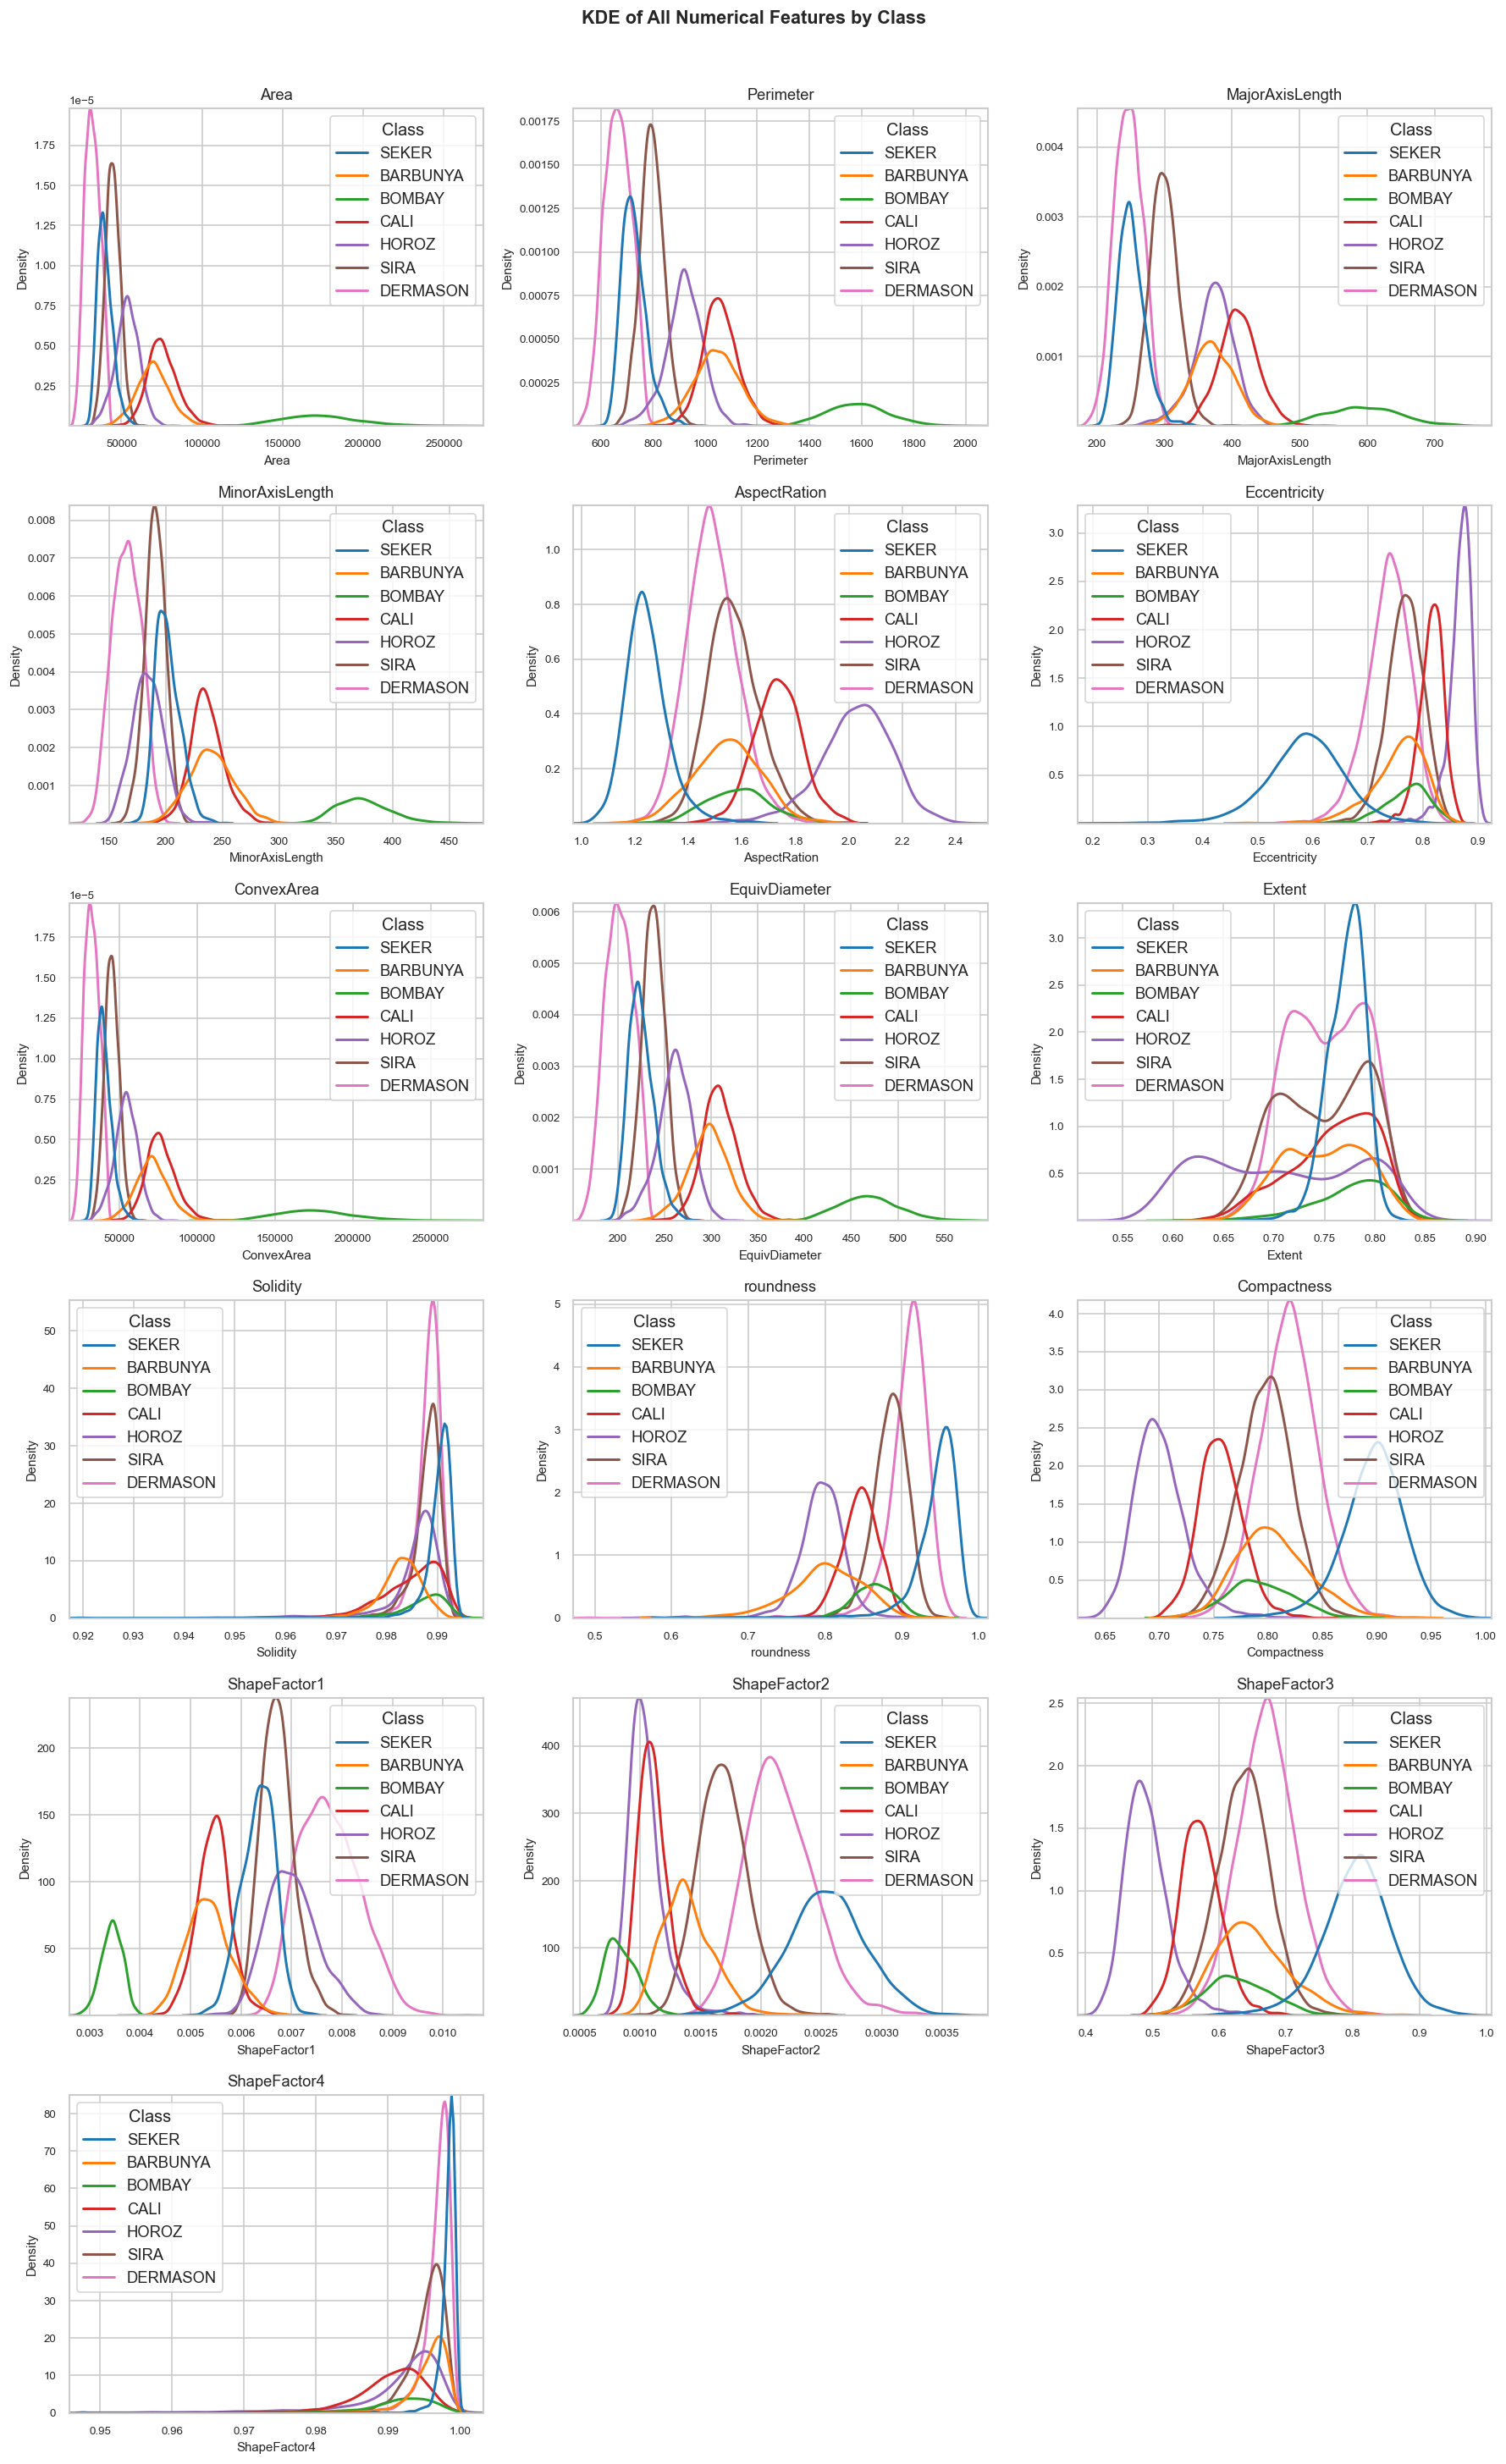

In [6]:
numerical_cols = df.select_dtypes(include="number").columns.tolist()
n_features = len(numerical_cols)

N_COLS = 3
n_rows = (n_features + N_COLS - 1) // N_COLS   # ceiling division

fig, axes = plt.subplots(nrows=n_rows, ncols=N_COLS,
                         figsize=(5 * N_COLS, 4 * n_rows))
axes = axes.flatten()

for idx, feature in enumerate(numerical_cols):
    sns.kdeplot(data=df, x=feature, hue="Class",
                linewidth=1.8, ax=axes[idx], warn_singular=False)
    axes[idx].set_title(feature)
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel("Density")
    axes[idx].autoscale(tight=True)

# Hide empty subplot slots
for idx in range(n_features, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("KDE of All Numerical Features by Class",
             fontsize=13, weight="bold", y=1.01)
plt.tight_layout()
plt.show()


### 5a · Skewness Assessment

In [7]:
skewness = df[numerical_cols].skew().sort_values(key=abs, ascending=False)

# Flag features with |skew| > 0.5 (moderate) or > 1.0 (high)
skew_df = skewness.reset_index()
skew_df.columns = ["Feature", "Skewness"]
skew_df["Severity"] = pd.cut(
    skew_df["Skewness"].abs(),
    bins=[-np.inf, 0.5, 1.0, np.inf],
    labels=["Low", "Moderate", "High"]
)
print(skew_df.to_string(index=False))


        Feature  Skewness Severity
           Area  2.952931     High
     ConvexArea  2.941821     High
   ShapeFactor4 -2.759483     High
       Solidity -2.550093     High
MinorAxisLength  2.238211     High
  EquivDiameter  1.948958     High
      Perimeter  1.626124     High
MajorAxisLength  1.357815     High
   Eccentricity -1.062824     High
         Extent -0.895348 Moderate
      roundness -0.635749 Moderate
   AspectRation  0.582573 Moderate
   ShapeFactor1 -0.534141 Moderate
   ShapeFactor2  0.301226      Low
   ShapeFactor3  0.242481      Low
    Compactness  0.037115      Low


**Modelling implication:** Features with **High** skewness can harm
distribution-sensitive models (Logistic Regression, LDA, SVM).
Apply **log** or **Box-Cox** transformation in the preprocessing pipeline
before feeding those models.


## 6 · Outlier Detection (IQR method, per class)

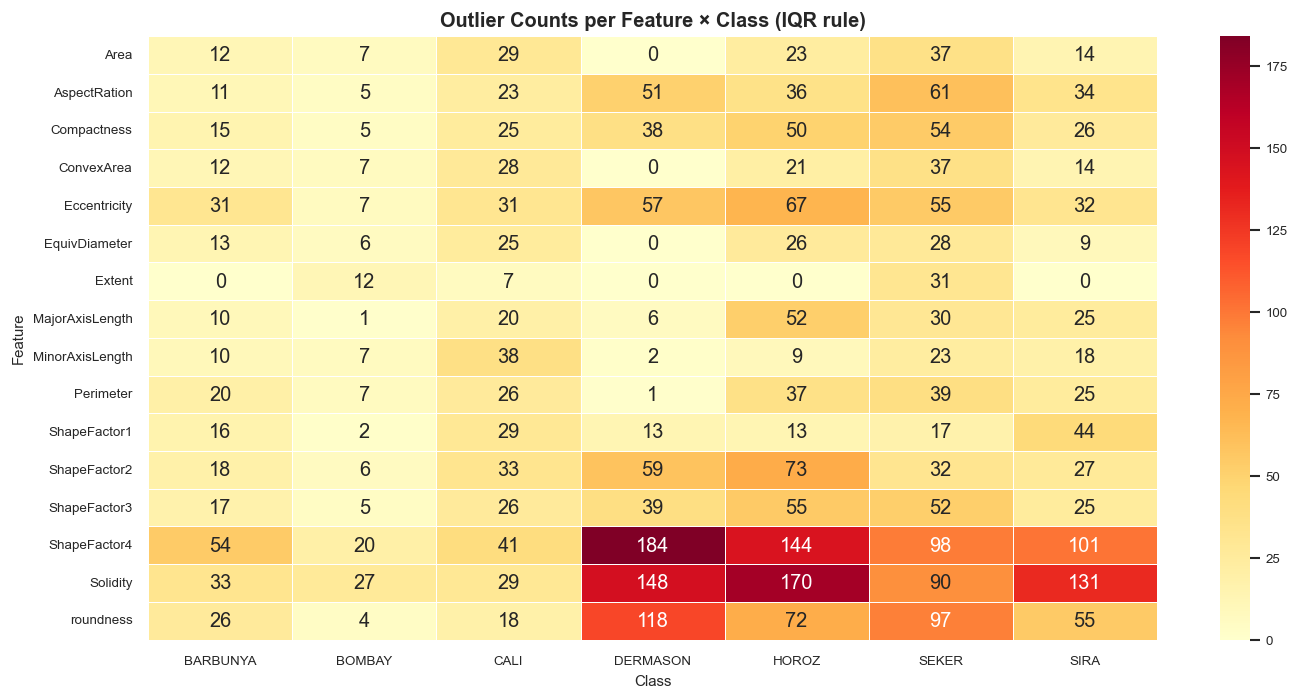

In [8]:
def count_outliers_iqr(series: pd.Series) -> int:
    """Return the number of values outside [Q1 - 1.5·IQR, Q3 + 1.5·IQR]."""
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return int(((series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)).sum())


# Build a tidy outlier-count DataFrame
records = []
for bean_class, group in df.groupby("Class"):
    for col in numerical_cols:
        records.append({
            "Class": bean_class,
            "Feature": col,
            "Outliers": count_outliers_iqr(group[col])
        })

outlier_df = pd.DataFrame(records)

# Pivot for a heatmap-style view
pivot = outlier_df.pivot(index="Feature", columns="Class", values="Outliers")

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt="d", cmap="YlOrRd", linewidths=0.4, ax=ax)
ax.set_title("Outlier Counts per Feature × Class (IQR rule)", fontsize=12, weight="bold")
plt.tight_layout()
plt.show()


**Recommendation:** Where outlier counts are non-trivial, consider:
1. **Capping / Winsorisation** — clip to the IQR bounds (preserves sample size)
2. **Median imputation** — replace outliers with the per-class median
3. **Robust scalers** — use `RobustScaler` instead of `StandardScaler` for
   scale-sensitive models (KNN, SVM, linear models)


## 7 · Feature Correlation

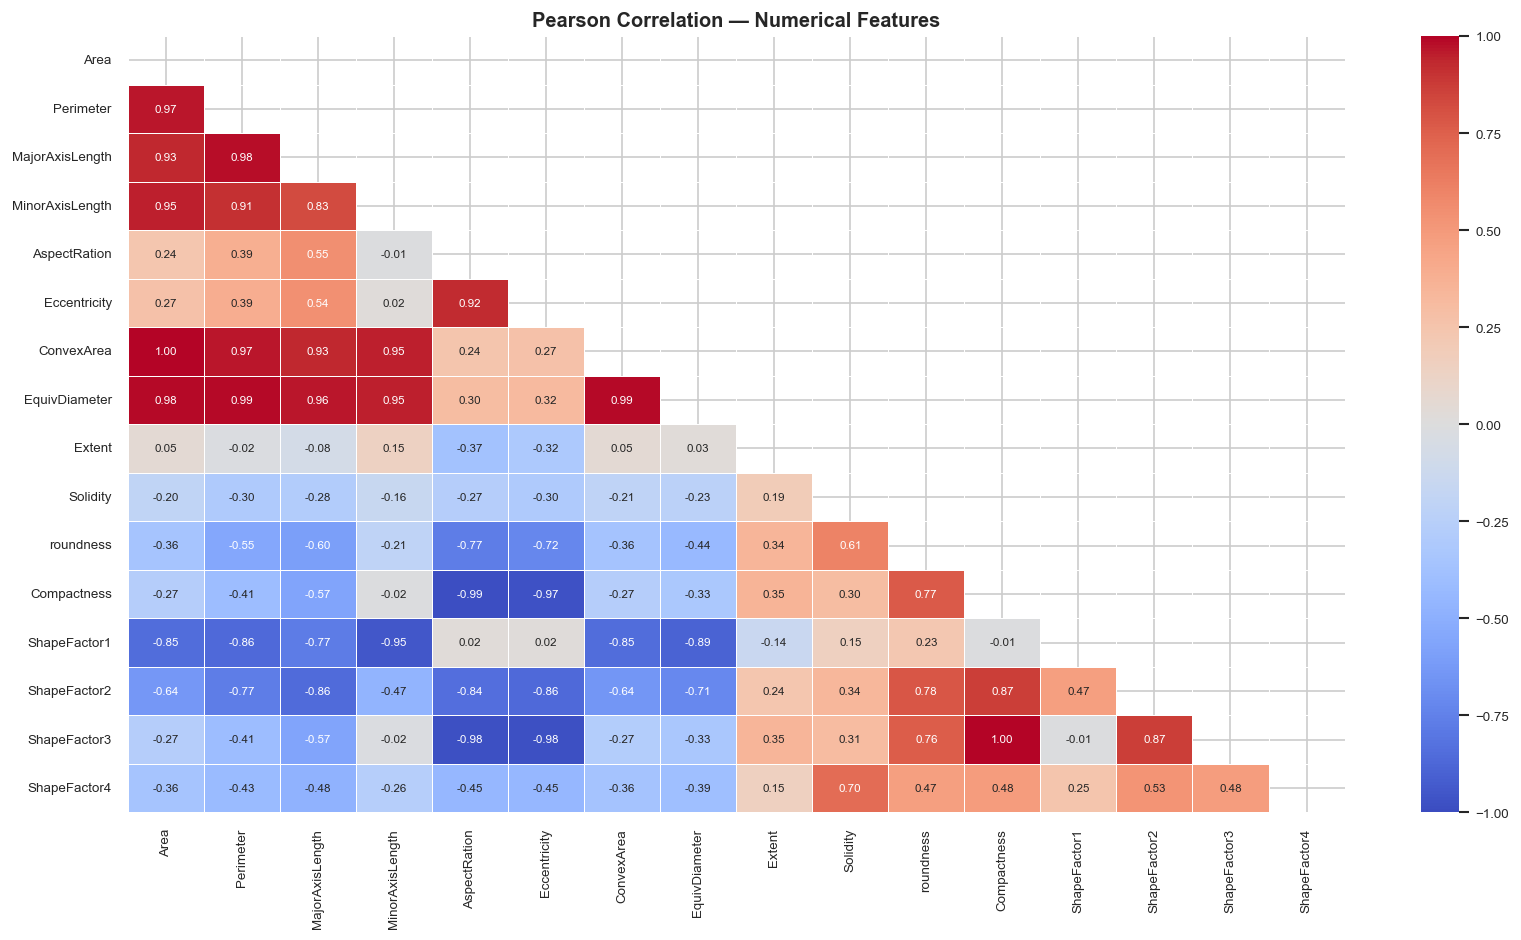

In [9]:
corr_matrix = df[numerical_cols].corr()

# Mask the upper triangle to avoid information duplication
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, vmin=-1, vmax=1,
    linewidths=0.3, annot_kws={"size": 7}, ax=ax
)
ax.set_title("Pearson Correlation — Numerical Features", fontsize=12, weight="bold")
plt.tight_layout()
plt.show()


In [10]:
# Identify highly correlated pairs (|r| > 0.90), excluding self-correlations
THRESHOLD = 0.90
upper_tri = corr_matrix.where(np.triu(np.ones_like(corr_matrix, dtype=bool), k=1))

high_corr_pairs = (
    upper_tri.stack()
    .reset_index()
    .rename(columns={"level_0": "Feature A", "level_1": "Feature B", 0: "Correlation"})
    .query("abs(Correlation) > @THRESHOLD")
    .sort_values("Correlation", ascending=False)
    .reset_index(drop=True)
)

print(f"Pairs with |r| > {THRESHOLD}:")
print(high_corr_pairs.to_string(index=False))


Pairs with |r| > 0.9:
      Feature A       Feature B  Correlation
           Area      ConvexArea     0.999939
    Compactness    ShapeFactor3     0.998686
      Perimeter   EquivDiameter     0.991380
     ConvexArea   EquivDiameter     0.985226
           Area   EquivDiameter     0.984968
      Perimeter MajorAxisLength     0.977338
      Perimeter      ConvexArea     0.967689
           Area       Perimeter     0.966722
MajorAxisLength   EquivDiameter     0.961733
           Area MinorAxisLength     0.951602
MinorAxisLength      ConvexArea     0.951339
MinorAxisLength   EquivDiameter     0.948539
MajorAxisLength      ConvexArea     0.932607
           Area MajorAxisLength     0.931834
   AspectRation    Eccentricity     0.924293
      Perimeter MinorAxisLength     0.913179
MinorAxisLength    ShapeFactor1    -0.947204
   Eccentricity     Compactness    -0.970313
   AspectRation    ShapeFactor3    -0.978592
   Eccentricity    ShapeFactor3    -0.981058
   AspectRation     Compactness  

**Multicollinearity** among the listed pairs can destabilise linear models and
inflate coefficient variance. Mitigation options:
- **Drop** one feature from each highly correlated pair
- **PCA** — collapse correlated groups into uncorrelated principal components
- **L1 / L2 regularisation** — let the model handle redundancy automatically


## 8 · Feature Importance via Random Forest

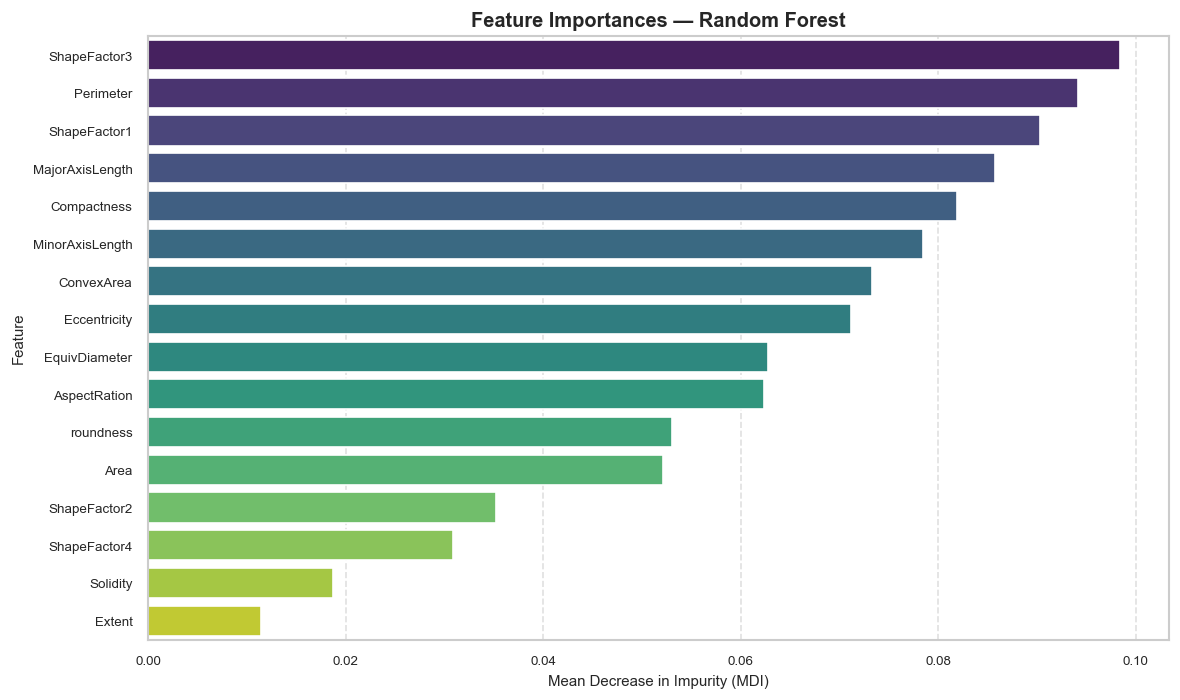

Top 5 features:
ShapeFactor3       0.098440
Perimeter          0.094203
ShapeFactor1       0.090310
MajorAxisLength    0.085742
Compactness        0.081895

► Top feature:    ShapeFactor3  (importance: 0.0984)
► Second feature: Perimeter  (importance: 0.0942)
► Pearson r between them: -0.408  → moderately correlated — use with caution together


In [11]:
X = df.drop(columns="Class")
y = df["Class"]

# Train a quick Random Forest — depth-limited for speed; tune for final use
rf = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
rf.fit(X, y)

importance_series = (
    pd.Series(rf.feature_importances_, index=X.columns)
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    x=importance_series.values, y=importance_series.index,
    hue=importance_series.index, palette="viridis", legend=False, ax=ax
)
ax.set_title("Feature Importances — Random Forest", fontsize=12, weight="bold")
ax.set_xlabel("Mean Decrease in Impurity (MDI)")
ax.set_ylabel("Feature")
ax.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# ── Dynamic insight based on actual results ────────────────────────────────
top1, top2 = importance_series.index[0], importance_series.index[1]
corr_top2 = df[[top1, top2]].corr().iloc[0, 1]

print(f"Top 5 features:")
print(importance_series.head().to_string())
print()
print(f"► Top feature:    {top1}  (importance: {importance_series[top1]:.4f})")
print(f"► Second feature: {top2}  (importance: {importance_series[top2]:.4f})")
print(f"► Pearson r between them: {corr_top2:.3f}  ", end="")
if abs(corr_top2) < 0.4:
    print("→ weakly correlated — good pair for 2D visualisation")
elif abs(corr_top2) < 0.7:
    print("→ moderately correlated — use with caution together")
else:
    print("→ highly correlated — consider using only one of them")


> The top features and their correlation are printed above — interpretation should follow the actual output.


## 9 · Class Separability — Top Feature Pair Plot

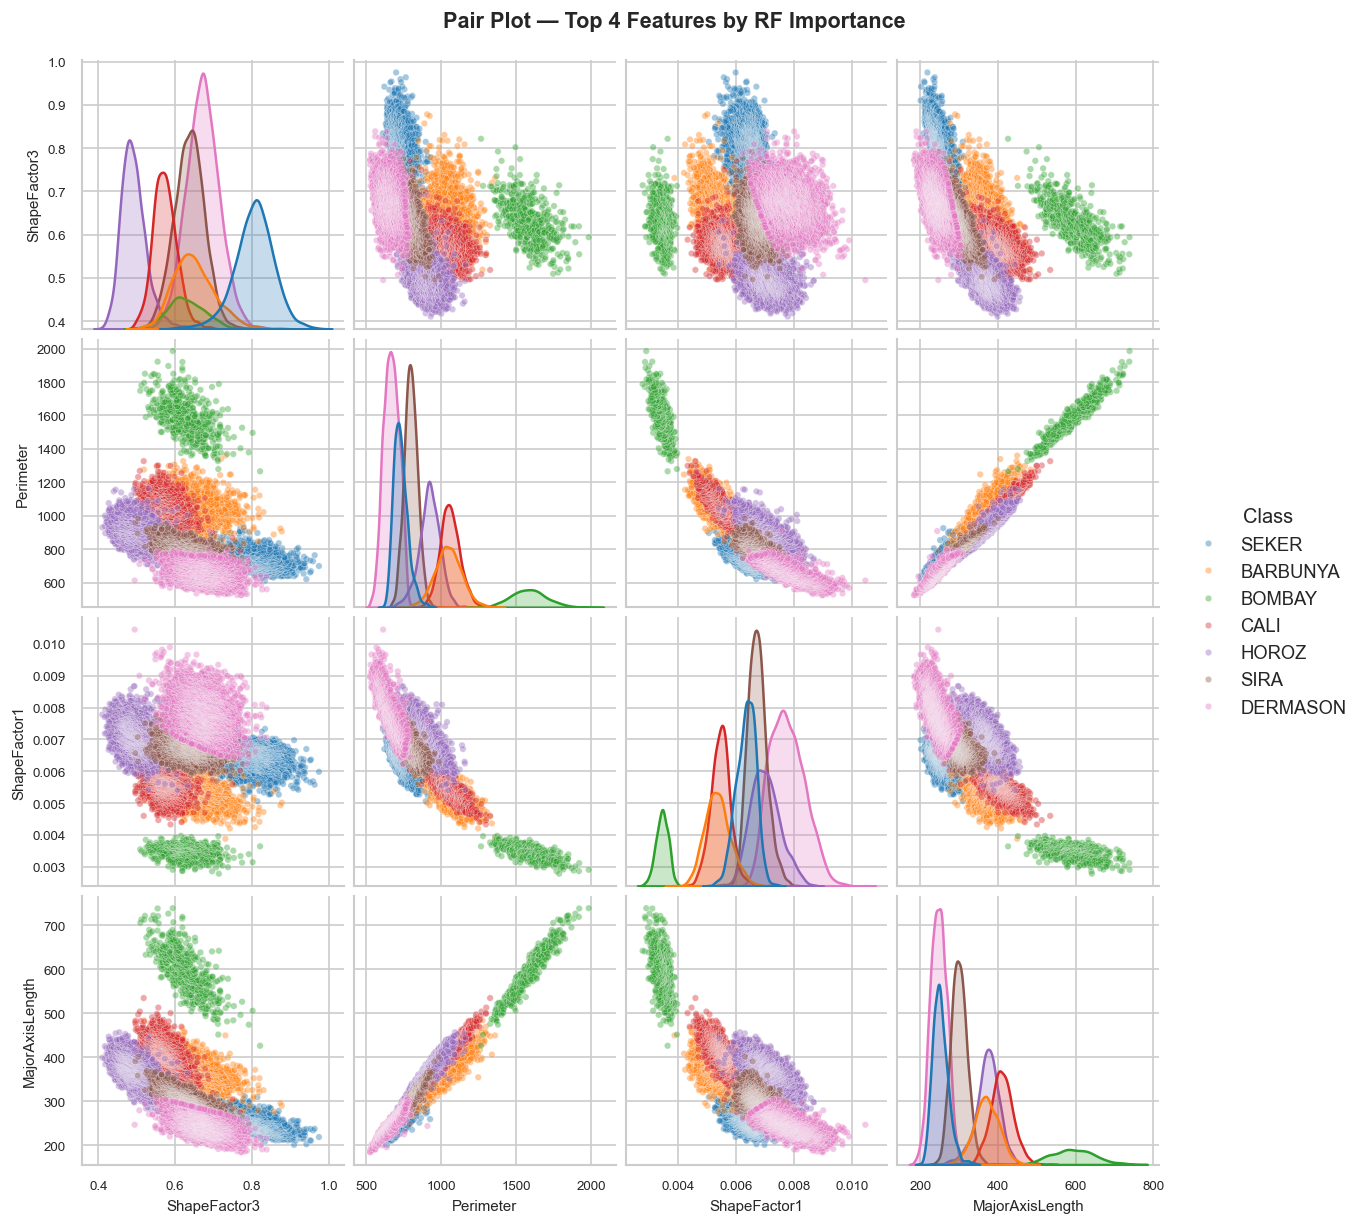

In [12]:
# Select the top-N most important features for the pair plot
TOP_N = 4
top_features = importance_series.head(TOP_N).index.tolist()

pair_df = df[top_features + ["Class"]]

g = sns.pairplot(
    pair_df, hue="Class", diag_kind="kde",
    plot_kws={"alpha": 0.4, "s": 15},
    diag_kws={"linewidth": 1.5}
)
g.figure.suptitle(f"Pair Plot — Top {TOP_N} Features by RF Importance",
                  y=1.02, fontsize=13, weight="bold")
plt.show()


**Class-similarity concern:** **SIRA** and **DERMASON** overlap substantially
in feature space, making them the most likely source of misclassification.
Dedicated post-hoc analysis or a targeted feature-engineering step may help
the model distinguish between them.


## 10 · EDA Summary & Recommendations

| Topic | Finding | Recommended Action |
|---|---|---|
| Missing values | None | No imputation needed |
| Class imbalance | Moderate (7 classes) | SMOTE / class weighting / macro-F1 evaluation |
| Skewness | Several features highly skewed | Log / Box-Cox transform before scale-sensitive models |
| Outliers | Scattered across classes | Winsorise or use RobustScaler |
| Multicollinearity | Several pairs with \|r\| > 0.90 | Drop redundant features or apply PCA |
| Top discriminators | Compactness, ShapeFactor1 | Prioritise in feature selection |
| Hard class pair | SIRA vs DERMASON | Investigate additional engineered features |
